<a href="https://colab.research.google.com/github/zeinabkaraki419-jpg/rdkit-learning/blob/main/06_Day_REVIEW/Review1_%3E5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 52.6 MB/s eta 0:00:00


In [5]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem import AllChem, DataStructs
from IPython.display import SVG ,display


(Aspirin)

Mol Object,SMILES,SVG

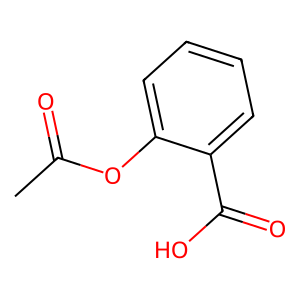

In [19]:
smiles_aspirin = "CC(=O)OC1=CC=CC=C1C(=O)O"
mol_aspirin = Chem.MolFromSmiles(smiles_aspirin)
img_aspirin = Draw.MolToImage(mol_aspirin , useSVG=True)
display(img_aspirin)

Caculate molecular descriptors & Lipinski's Rule of Five  for aspirin

In [20]:
# Calculate molecular descriptors for aspirin
mw = Descriptors.MolWt(mol_aspirin)
logp = Descriptors.MolLogP(mol_aspirin)
hbd = Descriptors.NumHDonors(mol_aspirin)
hba = Descriptors.NumHAcceptors(mol_aspirin)

print(f"Molecular Weight (MW): {mw:.2f} g/mol")
print(f"Partition Coefficient (LogP): {logp:.2f}")
print(f"Hydrogen Bond Donors (HBD): {hbd}")
print(f"Hydrogen Bond Acceptors (HBA): {hba}")

# Evaluate compliance with Lipinski's Rule of Five
passes_lipinski = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)
print(f"Does aspirin meet Lipinski's rules? {passes_lipinski}")

Molecular Weight (MW): 180.16 g/mol
Partition Coefficient (LogP): 1.31
Hydrogen Bond Donors (HBD): 1
Hydrogen Bond Acceptors (HBA): 3
Does aspirin meet Lipinski's rules? True


Substructure Searching & Fingerprint & Similarity

In [22]:
# Define the substructure pattern to search for using SMARTS (e.g., a benzene ring)
benzene_pattern = Chem.MolFromSmarts("c1ccccc1")

# Check if the substructure exists within the aspirin molecule
has_substructure = mol_aspirin.HasSubstructMatch(benzene_pattern)
print(f"Does the compound contain a benzene ring? {has_substructure}")

# Identify matching atoms and highlight them when rendering the image
matches = mol_aspirin.GetSubstructMatch(benzene_pattern)
img_highlighted = Draw.MolToImage(mol_aspirin, highlightAtoms=matches)
img_highlighted

# Define a second compound to compare with aspirin (e.g., Caffeine)
smiles_caffeine = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"
mol_caffeine = Chem.MolFromSmiles(smiles_caffeine)

# Compute Morgan Fingerprints (ECFP4 with radius=2 and 2048-bit length)
fp_aspirin = AllChem.GetMorganFingerprintAsBitVect(mol_aspirin, radius=2, nBits=2048)
fp_caffeine = AllChem.GetMorganFingerprintAsBitVect(mol_caffeine, radius=2, nBits=2048)

# Calculate Tanimoto Similarity between aspirin and caffeine
similarity_score = DataStructs.TanimotoSimilarity(fp_aspirin, fp_caffeine)

print(f"Tanimoto similarity score between aspirin and caffeine: {similarity_score:.4f}")

Does the compound contain a benzene ring? True
Tanimoto similarity score between aspirin and caffeine: 0.0889
